### Exploring LangChain Tool Calling
##### Tool is anything that an AI model can use to perform actions or access information beyond its built-in knowledge.

In [23]:
from pydantic import BaseModel
from typing import Literal, Dict, Any, Annotated, List
from operator import add
from jinja2 import Template
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [3]:
@tool
def dummy_tool(a: str, b: str) -> str:

    """Concatenate two strings.
    
    Args:
        a: The first string to concatenate
        b: The second string to concatenate
    
    Returns:
        A string of the two strings concatenated.
    """

    return f"Hello {a} and {b}"

In [9]:
llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort="none",
    use_responses_api=True
)
#llm_with_tools 
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto",
)

In [6]:
response = llm_with_tools.invoke("Use dummy tool to concatenate two random words")

In [7]:
response

AIMessage(content=[{'arguments': '{"a":"blue","b":"lamp"}', 'call_id': 'call_3MyNr8DISlrH6o50WWUyXr4r', 'name': 'dummy_tool', 'type': 'function_call', 'id': 'fc_099b3e52c1b24214006a57115a18648193b1d3babeccbf53a4', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_099b3e52c1b24214006a57115930e08193b4fd3c3f588ae61c', 'created_at': 1784090969.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_099b3e52c1b24214006a57115930e08193b4fd3c3f588ae61c', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'blue', 'b': 'lamp'}, 'id': 'call_3MyNr8DISlrH6o50WWUyXr4r', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 84, 'output_tokens': 23, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [8]:
response.usage_metadata

{'input_tokens': 84,
 'output_tokens': 23,
 'total_tokens': 107,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [10]:
response.tool_calls

[{'name': 'dummy_tool',
  'args': {'a': 'blue', 'b': 'lamp'},
  'id': 'call_3MyNr8DISlrH6o50WWUyXr4r',
  'type': 'tool_call'}]

### Agent Graph

In [11]:
@tool
def append_vibes(query: str, vibe: str) -> str:
    """Takes in a query and a vibe and returns a string with the query and vibe appended.

    Args:
        query: The query to append the vibe to.
        vibe: The vibe to append to the query.

    Returns:
        A string with the query and vibe appended.
    """
    
    return f"{query} {vibe}"

In [16]:
class State(BaseModel):
    query: str
    # add is used because multiple nodes in a LangGraph workflow may update the messages field, and LangGraph needs to know how to combine those updates instead of overwriting the existing list.
    messages: Annotated[List[Any], add] = []
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False

In [17]:
def agent_node(state: State) -> dict:

    #jinja template
    prompt_template = """You are an assistant that is generating vibes for a user.

## Instructions

- You need to use the tools to add vibes to the user's query.
- Add a random vibe to the user's query.

## User Query
{{ query }}
"""

    template = Template(prompt_template)
    prompt = template.render(
        query = state.query
    )

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    #llm_with_tools 
    llm_with_tools = llm.bind_tools(
        [append_vibes],
        tool_choice="auto",
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content= prompt)
        ]
    )

    return {
        "messages": [response]
    }

In [18]:
def tool_router(state : State) -> str:
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [21]:
workflow = StateGraph(State)

tools = [append_vibes]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)

workflow.add_edge(START, "agent_node")

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)

workflow.add_edge("tool_node", END)

graph = workflow.compile()

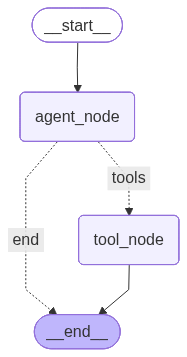

In [24]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
initial_state = {
    "query": "Give me some vibes!"
}

In [26]:
result = graph.invoke(initial_state)

In [27]:
result

{'query': 'Give me some vibes!',
 'messages': [AIMessage(content=[{'arguments': '{"query":"Give me some vibes!","vibe":"with a dreamy, neon-lit, late-night-cafe energy"}', 'call_id': 'call_p2mhXVHlAvq0wLuc1rmOxeFk', 'name': 'append_vibes', 'type': 'function_call', 'id': 'fc_09979ee0a5610e1c006a57211d9a1081948bdba06856943eb3', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_09979ee0a5610e1c006a57211cd2588194a1c9a8ddb4d44847', 'created_at': 1784095004.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_09979ee0a5610e1c006a57211cd2588194a1c9a8ddb4d44847', tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibes!', 'vibe': 'with a dreamy, neon-lit, late-night-cafe energy'}, 'id': 'call_p2mhXVHlAvq0wLuc1rmOxeFk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 14

In [33]:
result['messages'][1]

ToolMessage(content='Give me some vibes! with a dreamy, neon-lit, late-night-cafe energy', name='append_vibes', tool_call_id='call_p2mhXVHlAvq0wLuc1rmOxeFk')